# Laboratorio de Redes Neuronales Convolucionales (CNN)

Observación: El código utilizado aquí esta basado mayoritariamente en el presentado en el libro *Hands-On Machine Learning with Scikit-Learn Keras & TensorFlow*

* Se cargan las librerías

In [ ]:
import sys
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

* Se carga la configuración para la visualización

In [ ]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

* Se recomienda usar GPU porque los modelos de CNN toman mucho tiempo en entrenar.

In [ ]:
IS_COLAB = "google.colab" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")

No GPU was detected. Neural nets can be very slow without a GPU.
Go to Runtime > Change runtime and select a GPU hardware accelerator.


## Implementación de capas convolucionales con Keras

* Se descarga un conjunto de datos con dos imágenes: una es una torres china y la otra es una flor

In [ ]:
from sklearn.datasets import load_sample_images

dataset = load_sample_images()
print(len(dataset["images"]))

2


* Características de la primera imagen.

In [ ]:
first_img_data = dataset["images"][0]
first_img_data.shape

(427, 640, 3)

* Se visualiza la primera imagen.

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

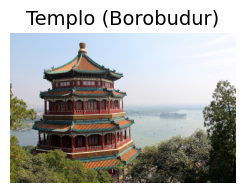

In [ ]:
plt.subplot(1, 2, 1)
plt.imshow(first_img_data)
plt.title("Templo (Borobudur)")
plt.axis('off')

* Características de la segunda imagen.

In [ ]:
second_img_data = dataset["images"][1]
second_img_data.shape

(427, 640, 3)

* Se visualiza la segunda imagen.

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

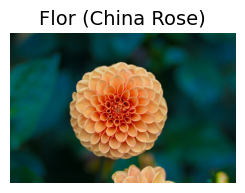

In [ ]:
plt.subplot(1, 2, 2)
plt.imshow(second_img_data)
plt.title("Flor (China Rose)")
plt.axis('off')

* Se carga las dos imágenes de muestra.
* Se escala los valores de píxel al rango 0-1.
* Se hace un recorte centrado para obtener imágenes pequeñas de 70×120.

In [ ]:
images = dataset["images"]
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

Se tienen un vector de 4D, esto es:
* Son dos imágenes.
* La imágen es de 70 X 120 píxeles
* Cada píxel tiene un vector de dimensión 3 que corresponde a los valores de los colores RGB.

In [ ]:
images.shape

TensorShape([2, 70, 120, 3])

* Se crea un capa convolucional que recibe como entrada las dos imágenes.
* La capa tiene 32 filtros.
* Cada filtro (kernel) tiene de tamaño 7 X 7.
* Por defecto la opción predeterminada `padding="valid"`, que significa que no hay ningún relleno de ceros.
* La nueva capa de denomina mapa de característica.

In [ ]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7) # padding="valid"
fmaps = conv_layer(images)

* Se muestra la configuración de la capa resultante

In [ ]:
fmaps.shape

TensorShape([2, 64, 114, 32])

* Se muestra los mapas caracteríticos de cada imagen

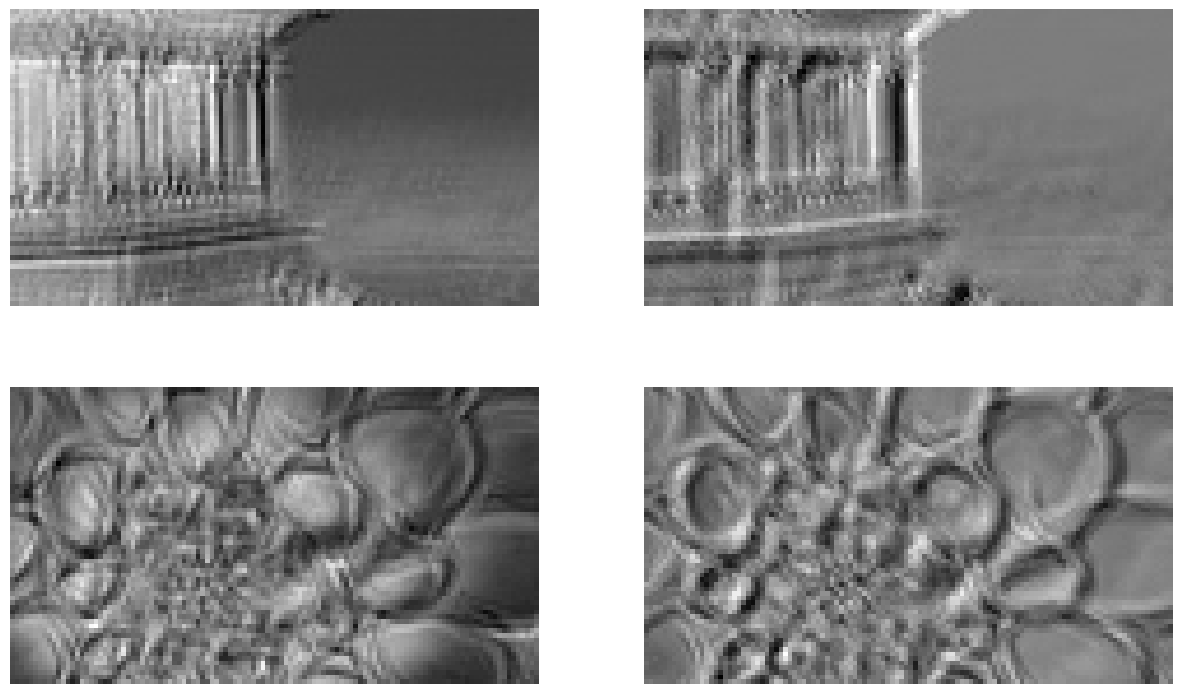

In [ ]:
plt.figure(figsize=(15, 9))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

* Con `padding="same"`, entonces las entradas se rellenan con suficientes ceros por todos los lados
* El mapa de característica de salida tiene el mismo tamaño que la entrada.

In [ ]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same")
fmaps = conv_layer(images)

:* Se muestra la dimensión del mapa de característica.

In [ ]:
fmaps.shape

TensorShape([2, 70, 120, 32])

Ejemplo adicional:
* Misma configuración anterior.
* Ejemplo con stride = 2.

In [ ]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same",
                                    strides=2)
fmaps = conv_layer(images)
fmaps.shape

TensorShape([2, 35, 60, 32])

* Se ilustra el `padding="valid"` y `padding="same"`
* Se usa `padding=1`

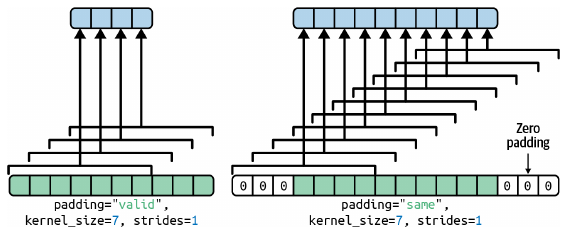

* Se ilustra el `padding="valid"` y `padding="same"`
* Se usa `padding=2`

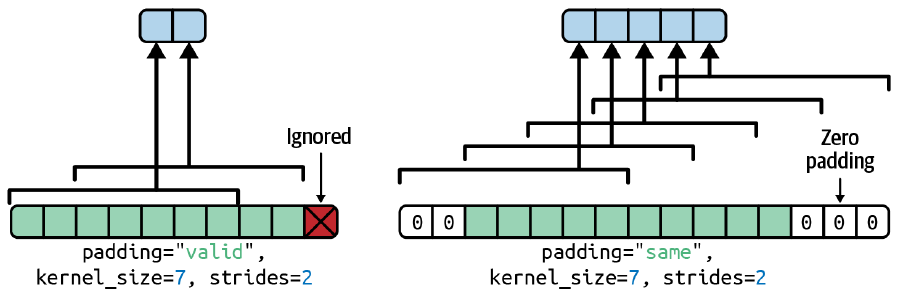

* La nueva capa tiene los pesos y el sesgo.
* Se obtiene los valores del kernel y el sesgo.
* El kernel tiene cuatro dimensiones  [kernel_height, kernel_width, input_channels,
output_channels]

In [ ]:
kernels, biases = conv_layer.get_weights()
kernels.shape

(7, 7, 3, 32)

* Se muestra los valores del sesgo.
* El sesgo es un vector (1D).


In [ ]:
biases.shape

(32,)

## Capas de agrupamiento (Pooling Layers)
* Se define la dimensión del agrupamiento.
* Se define si se aplica la función "max pooling" o "average pooling"

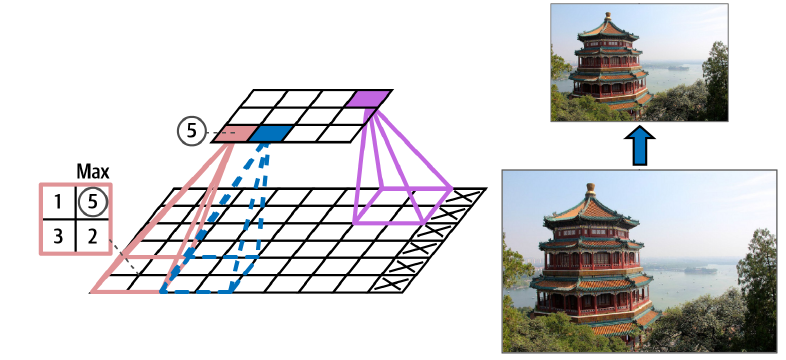


* Se crea un Pool de 2 X 2 usando max pooling.

In [ ]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=2)

* Ilustración de Max Pooling en una CNN
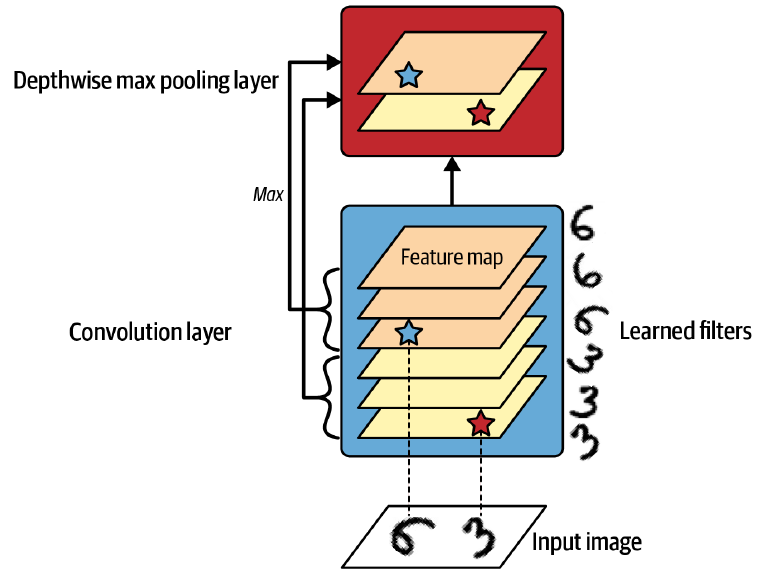

In [ ]:
output = max_pool(images)

* Se muestra la capa de agrupamiento de la primera imagen con stride = 2.


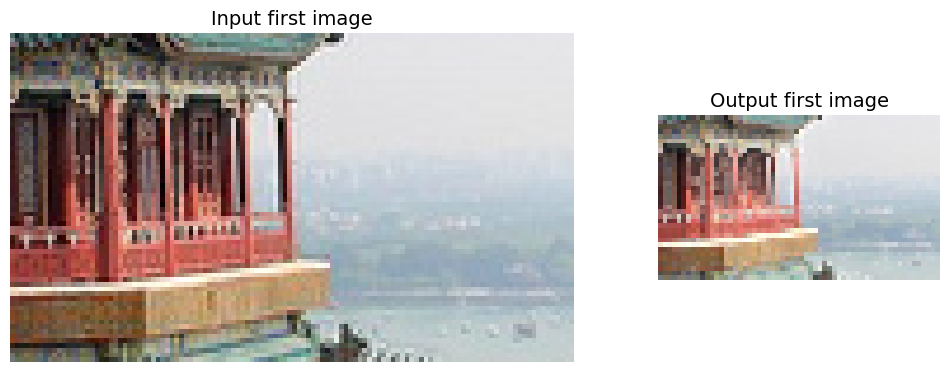

In [ ]:
import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input first image")
ax1.imshow(images[0])  # plot the 1st image
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output first image")
ax2.imshow(output[0])  # plot the output for the 1st image
ax2.axis("off")
plt.show()

* Se muestra la capa de agrupamiento de la segunda imagen con stride = 2.


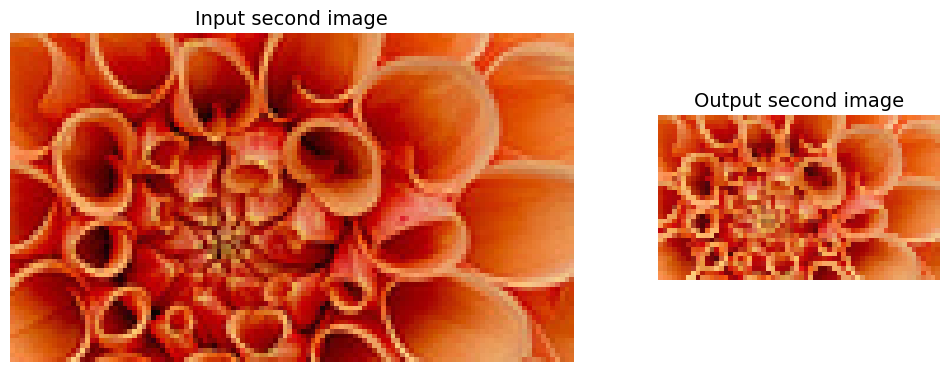

In [ ]:
import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input second image")
ax1.imshow(images[1])  # plot the 2nd image
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output second image")
ax2.imshow(output[1])  # plot the output for the 2nd image
ax2.axis("off")
plt.show()

In [ ]:
class DepthPool(tf.keras.layers.Layer):
  def __init__(self, pool_size=2, **kwargs):
    super().__init__(**kwargs)
    self.pool_size = pool_size
  def call(self, inputs):
    shape = tf.shape(inputs) # shape[-1] is the number of channels
    groups = shape[-1] // self.pool_size # number of channel groups
    new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
    return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

* Usando agrupamiento promedio con Keras

In [ ]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

* Si aplica a las imágenes obenmos los valores promedios de Red, Green y Blue.

In [ ]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.64338624, 0.5971759 , 0.5824972 ],
       [0.76306933, 0.2601113 , 0.10849128]], dtype=float32)>

## Arquitecturas de la CNN

* Arquitectura típica de una CNN
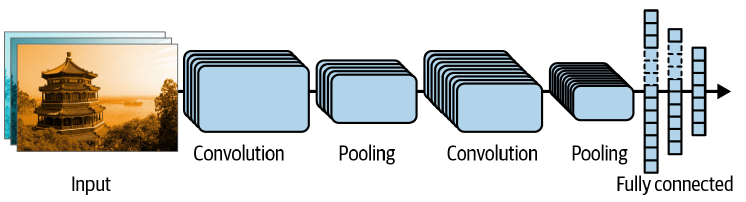

* Se carga el conjunto de datos Fashion MNIST

In [ ]:
mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = np.expand_dims(X_train_full, axis=-1).astype(np.float32) / 255
X_test = np.expand_dims(X_test.astype(np.float32), axis=-1) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


* Se crea una CNN para hacer clasificación del conjunto de datos Fashion MNIST.

In [ ]:
from functools import partial

DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same", activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
  DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
  tf.keras.layers.MaxPool2D(),
  DefaultConv2D(filters=128),
  DefaultConv2D(filters=128),
  tf.keras.layers.MaxPool2D(),
  DefaultConv2D(filters=256),
  DefaultConv2D(filters=256),
  tf.keras.layers.MaxPool2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(units=128, activation="relu",
  kernel_initializer="he_normal"),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(units=64, activation="relu",
  kernel_initializer="he_normal"),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(units=10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* Se compila el modelo.
* Se hace las predicciones en el conjunto de datos.

In [ ]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)
X_new = X_test[:10]  # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 846s 490ms/step - accuracy: 0.7600 - loss: 0.6907 - val_accuracy: 0.8724 - val_loss: 0.3634
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 800s 465ms/step - accuracy: 0.8645 - loss: 0.4016 - val_accuracy: 0.8864 - val_loss: 0.3062
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 788s 457ms/step - accuracy: 0.8872 - loss: 0.3364 - val_accuracy: 0.8996 - val_loss: 0.2742
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 779s 453ms/step - accuracy: 0.8982 - loss: 0.3016 - val_accuracy: 0.9072 - val_loss: 0.2707
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 807s 456ms/step - accuracy: 0.9050 - loss: 0.2777 - val_accuracy: 0.9044 - val_loss: 0.2865
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 798s 454ms/step - accuracy: 0.9134 - loss: 0.2596 - val_accuracy: 0.9156 - val_loss: 0.2577
Epoch 7/10
1268/1719 ━━━━━━━━━━━━━━━━━━━━ 3:19 443ms/step - accuracy: 0.9195 - loss: 0.2347

### Le-Net 5
* Propuesta por Lecun et al. en 1998.
* Es una de las primeras CNN que compite con el estado del arte en la época.
* Ampliamente usada en la detección de dígitos en los bancos.

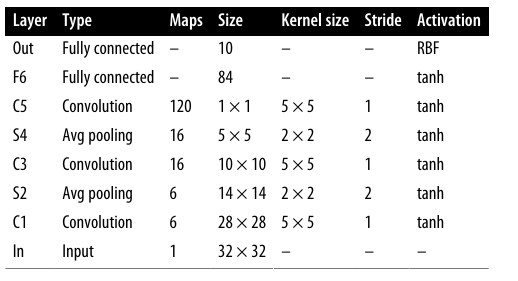

* Ilustración de la arquitectura de Len-Net-5.
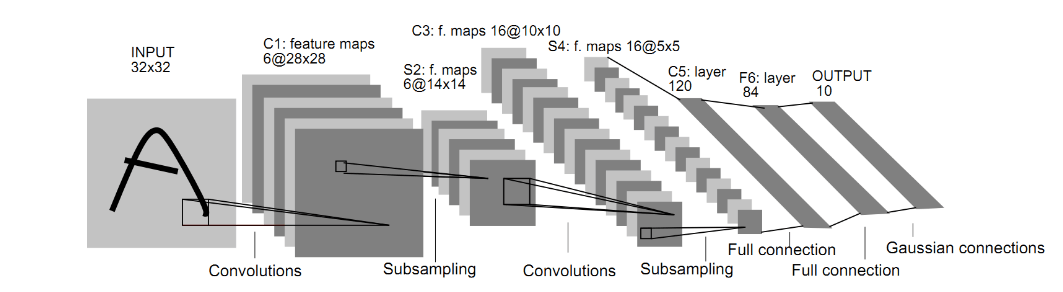

## AlexNet

* Ganó el ImageNet Large Scale Visual Recognition Challenge (ILSVRC) del 2012 por largo margen.
* Su tasa de error fue de 17%.
* Similar a LeNet-5 para más larga y profunda.




* Arquitectura de AlexNet


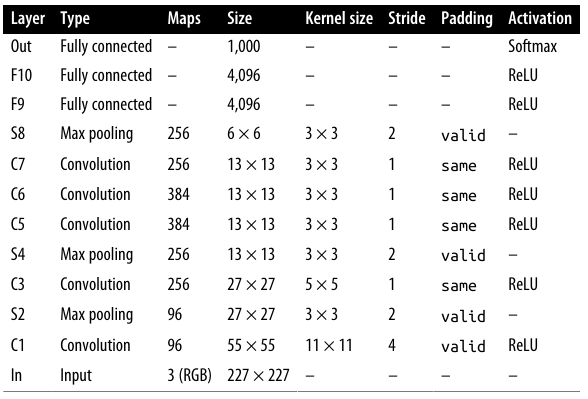

## ResNet

* Ganó el ILSVRC el 2015 con una tasa de error de 3.6%.
* Es CNN de 152 capas, con variantes de 34, 50 y 101 capas.
* Se *skip connections* donde una la salida de una capa alimenta otra varios niveles abajo.
* Se crea las redes residuales: Se quiere aprender $h(x)$, si agregas a la salida $x$ (*skip connection*), entonces la red tiene que aprender $h(x) - x$.

* Ilustración de una red residual

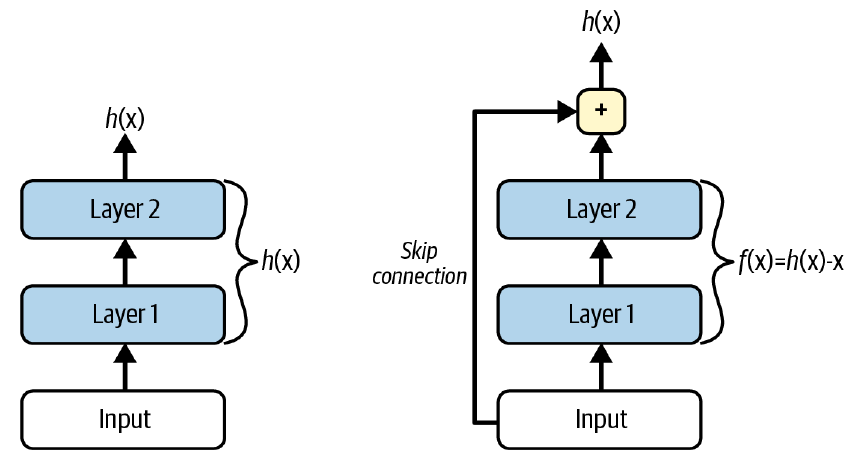

* Regular deep neural network (izquierda) y deep residual network (derecha)

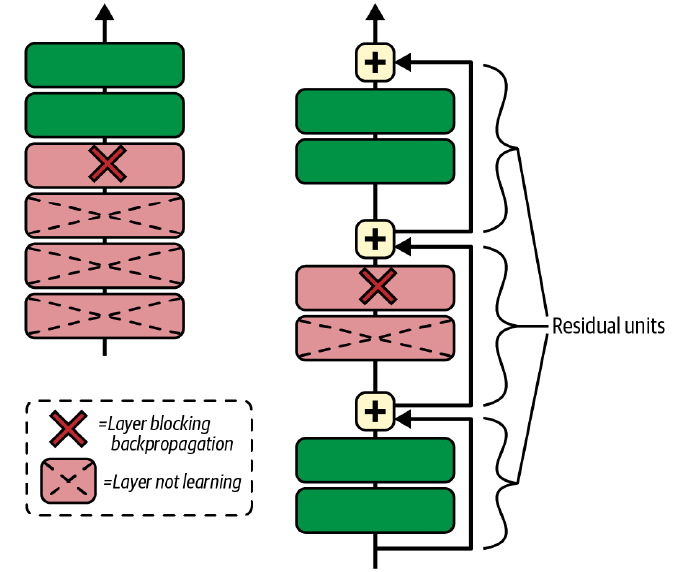

* Arquitectura ResNet

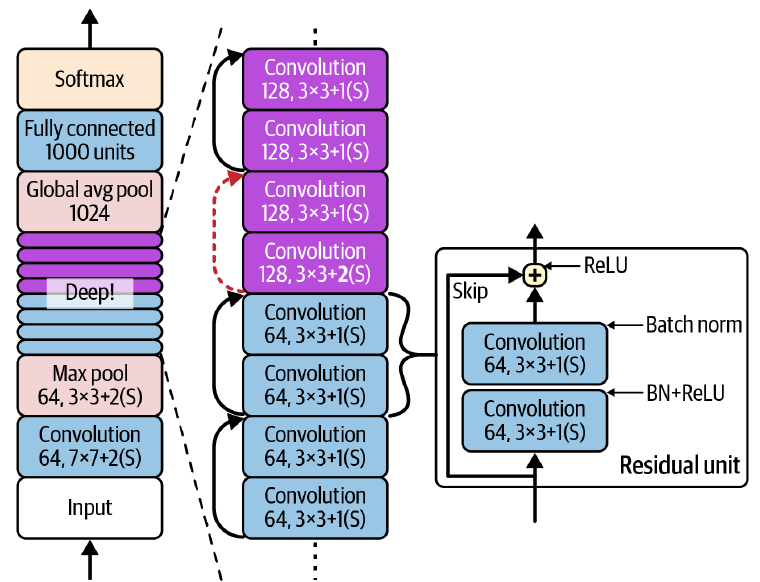

### Implementación de una CNN ResNet-34 utilizando Keras

In [ ]:
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [ ]:
model = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=7, strides=2, input_shape=[224, 224, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"),
])
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation="softmax"))

## Modelos Pre-Entrenados

* En lugar de crear un modelo desde cero, se puede usar un modelo preentrenado.
* Lista de modelos preentrenados [https://keras.io/api/applications](https://keras.io/api/applications)
* La elección del modelo va a depender del tipo de aplicación a resolver.

### Lista parcial de modelos pre entrenados disponibles en Keras

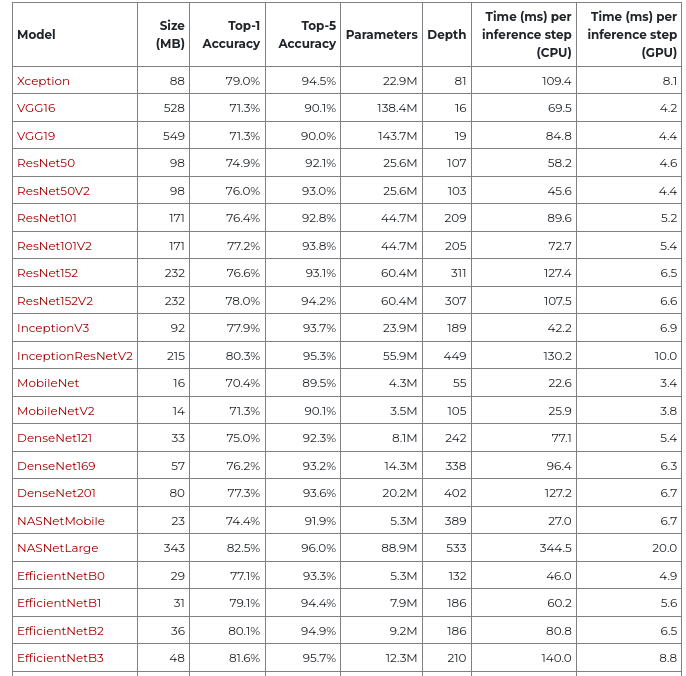

## Usando modelos pre entrendos de Keras

* La idea es usar modelos pre entrenados para resolver problemas en lugar de crear una modelo desde cero.

### Ejemplo de uso de un modelo pre entrenado

* Se carga el modelo ResNet-50

In [ ]:
model = tf.keras.applications.ResNet50(weights="imagenet")

* Se carga el conjunto de datos de imagenes

In [ ]:
K = tf.keras.backend
images = K.constant(load_sample_images()["images"])
images_resized = tf.keras.layers.Resizing(height=224, width=224,
                                          crop_to_aspect_ratio=True)(images)

* Se preprocesa la imagen

In [ ]:
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized)

* Podemos usar el modelo para hacer predicciones.

In [ ]:
Y_proba = model.predict(inputs)
Y_proba.shape

* Se tiene dos imagenes y 1000 posibles clases de imágenes:
* Se muestra las principales predicciones del modelo

In [ ]:
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")

* Se muestras las imagenes pre procesdas

In [ ]:
plt.figure(figsize=(10, 6))
for idx in (0, 1):
    plt.subplot(1, 2, idx + 1)
    plt.imshow(images_resized[idx] / 255)
    plt.axis("off")

plt.show()